In [ ]:
import numpy as np#将numpy库（用于python里的科学计算）导入，并简称为np
import matplotlib.pyplot as plt#将matplotlib.pyplot（用于python里的绘图）导入，并简称为plt
from scipy.io import loadmat#将scipy.io（用于python里的加载MATLAB的mat文件）导入，将数据加载为字典
import random
import seaborn as sns#用于python里的统计绘图
sns.set_theme()#提升绘图的品质

In [ ]:
data = loadmat('cluster_dataset.mat')#用loadmat函数读取cluster_dataset.mat文件，
#将数据加载为字典
#这个文件里面的数据就是二维平面上的点

In [ ]:
X = data['data']#因此，x等于data之后，x就是一个二维数组(列表的列表，第一层为样本，第二层为特征)
x1 = np.array([i[0] for i in X])#自定义X1为X中的第一列，含义为第一个特征
x2 = np.array([i[1] for i in X])#自定义X2为X中的第二列，含义为第二个特征
#print(X[0])
#print(X.shape)

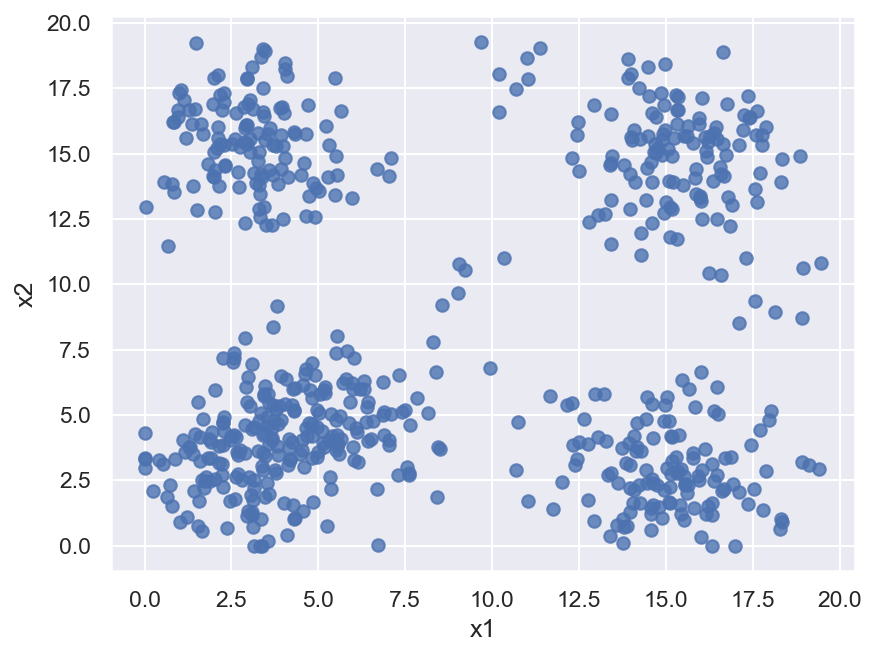

In [ ]:
plt.figure(dpi=150)
plt.scatter(x1,x2,color='b',alpha=0.8)
plt.xlabel('x1')#定义x轴的标签为x1
plt.ylabel('x2')
plt.show()#这里是在绘制下方的散点图

In [ ]:
#预设聚类簇数k：请观察数据集散点图，预计聚类簇数k
k = 4 #因为一共四团

In [ ]:
#随机选择数据集中k个点作为初始聚类中心
def init_centers(X,k):
    np.random.seed(42)#设置随机种子，确保结果可复现
    a1 = np.random.choice(X.shape[0],k,replace=False)#从X.shape[0]个样本中不放回地随机取k个点作为初始中心
    #shape的作用是显示数组的维度，这里显示的是样本数
    centers = [X[i] for i in a1]#将a1中的索引转换为样本点
    """
    输入：X:数据集(ndarray), k：预设的聚类簇数(int)
    输出：centers：初始化的中心集（建议：元素为ndarray的list)
    可能使用的函数：random.randint
    注意：需保证随机取的样本不重复
    """
    
    return centers

In [ ]:
#向量欧氏距离计算，用于计算每个样本和中心的距离，可用于簇分配和代价函数计算
def distance(v1, v2):
    distance = np.sqrt(np.sum((v1 - v2) ** 2))
    """
    输入：v1:样本(ndarray), v2:当前对应的中心(ndarray)
    输出：distance:欧氏距离(float/ndarray)
    """
   
    return distance

In [ ]:
#将样本分配到距离最近的中心所在的簇
def cluster_assignment(X, centers):
    assignment = {i: [] for i in range(len(centers))}#把center里的每个中心的索引作为key，value为空列表
    # 遍历数据集中的每一个样本
    for point in X:
        # 计算当前样本到每个中心的欧氏距离
        distances = []
        for c in centers:
            distances.append(np.sqrt(np.sum((point - c) ** 2)))
        closest_cluster = np.argmin(distances)# 找到最小距离的点
        assignment[closest_cluster].append(point)# 将该样本点添加到对应簇的列表中
    
    """
    输入：X:数据集(ndarray), centers：当前中心集（建议：元素为ndarray的list)
    输出：assignment(建议：字典：key为簇标号、value为元素是ndarray的list)
    可能使用的函数：np.argmin
    注意：list和array在某些计算时的转换
    """
    
    return assignment

In [ ]:
#代价函数：所有数据点到当前对应中心的欧氏距离之和的平均值
def cost_function(assignment, centers):
    total_distance = 0.0
    total_samples = 0
    for key, points in assignment.items():
        center = centers[key]# 获取当前簇的中心
        for point in points:
            # 计算点到中心的欧氏距离
            dist = np.sqrt(np.sum((point - center) ** 2))
            total_distance += dist  
            total_samples += 1
    
    cost = total_distance / total_samples # 平均值等于所有样本到中心的距离除以样本总数
    #计算所有点到各自中心点的距离并相加，最后取得最小的那个，这个时候就是四个簇都找到各自真正的中心点的时候
    #把cost当作列表，并把它放进循环里面，就可算出每个簇的cost
    """
    输入：X:数据集(ndarray), centers：当前中心（建议：元素为ndarray的list)
    输出：cost:代价函数值（float/ndarray）
    可能使用的函数：np.argmin
    注意：list和array在使用np函数计算时的转换
    """
    
    return cost

In [ ]:
#更新中心,满足停机条件（聚类中心不再改变）时结束更新
def center_update(assignment, centers):
    new_centers = [] #存储新中心点
    stop = 1 #先假设停机（即认为第一次规定的中心点就是最终的中心点）
    for i in range(len(centers)):#遍历每个中心点
        cluster_points = assignment[i] # 获取属于目前中心点i的所有样本点
        if len(cluster_points) == 0: # 如果该簇没有分配到任何样本点
            new_center = centers[i] # 保留原中心（或者可以随机重新初始化，但简单处理为保留）（其实这个样本点已经没用了，但是因为k固定，直接删除这个点可能会导致少一个中心点，之后还需添加，这就增加了工作量）
            #np.random.choice(X.shape[0])，如果想要直接更改这个点的话
        else:
            # 将列表中的样本点转换为 NumPy 数组，方便求均值
            # 注意：cluster_points 中的每个元素已经是 ndarray，直接堆叠即可
            points_array = np.array(cluster_points)   # 形状 (样本数, 维度)
            new_center = np.mean(points_array, axis=0)  # 对每一列求均值，得到新的中心
        new_centers.append(new_center)#将新中心点添加到新中心点列表中
        if not np.array_equal(new_center, centers[i]):  # 检查新中心是否与旧中心完全相同（数值上）
            stop = 0        # 至少有一个中心改变了，不能停机

    
    """
    输入：assignment(建议：字典：key为簇标号、value为元素是ndarray的list), centers：当前中心（建议：元素为ndarray的list)
    输出：new_centers:更新的中心集（建议：元素为ndarray的list), stop：停机条件标识（不停机：0/停机：1）
    可能使用的函数：np.mean
    注意：list和array在使用np函数计算时的转换
    """
    
    return new_centers, stop

In [ ]:
#聚类可视化
def plot_clustering(assignment, centers, epoch):
    color = ['r', 'b', 'c', 'g', 'k', 'w', 'y', 'm']
    plt.figure(dpi=150)
    for k in range(len(centers)):
        cluster = np.array(assignment[k])
        if len(cluster) == 0:
            continue
        x1 = cluster[:,0]
        x2 = cluster[:,1]
        plt.scatter(x1, x2, c=color[k])
        plt.xlabel('x1')
        plt.ylabel('x2')
    for k in range(len(centers)):
        x1 = centers[k][0]
        x2 = centers[k][1]
        plt.scatter(x1, x2, c='k', marker = '*')
        plt.xlabel('x1')
        plt.ylabel('x2')
    plt.title('epoch'+ str(epoch))
    plt.show()

In [ ]:
#kmeans及可视化
def kmeans(X, k, max_epoch, plot=True):
    
     centers = init_centers(X, k) #定义为初始化的中心点

     # 迭代优化
     for epoch in range(max_epoch): #max_epoch为最大训练轮数
        assignment = cluster_assignment(X, centers) # 分配样本到最近的簇
        if plot: #可视化当前迭代的聚类结果
            plot_clustering(assignment, centers, epoch)
        new_centers, stop = center_update(assignment, centers)# 更新聚类中心，并检查是否停机
        if stop == 1: 
            break
        # 否则用新中心继续下一轮
        centers = new_centers

    # 计算最终的代价函数值
     cost = cost_function(assignment, centers)
     """
    输入：X:数据集(ndarray), k：预设的聚类簇数(int), max_epoch：最大训练轮数(int), plot:是否可视化（True/False)
    输出：assignment(建议：字典：key为簇标号、value为元素是ndarray的list), cost:最终的代价函数值，用于k-cost曲线的绘制（float/ndarray）
    """
    
     return assignment, cost

In [ ]:
max_epoch = 200 

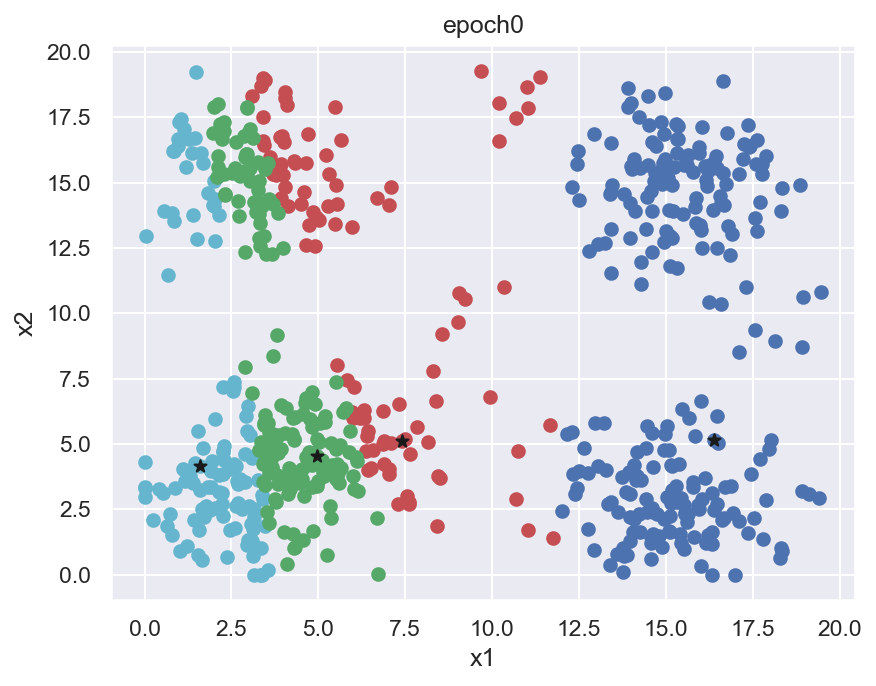

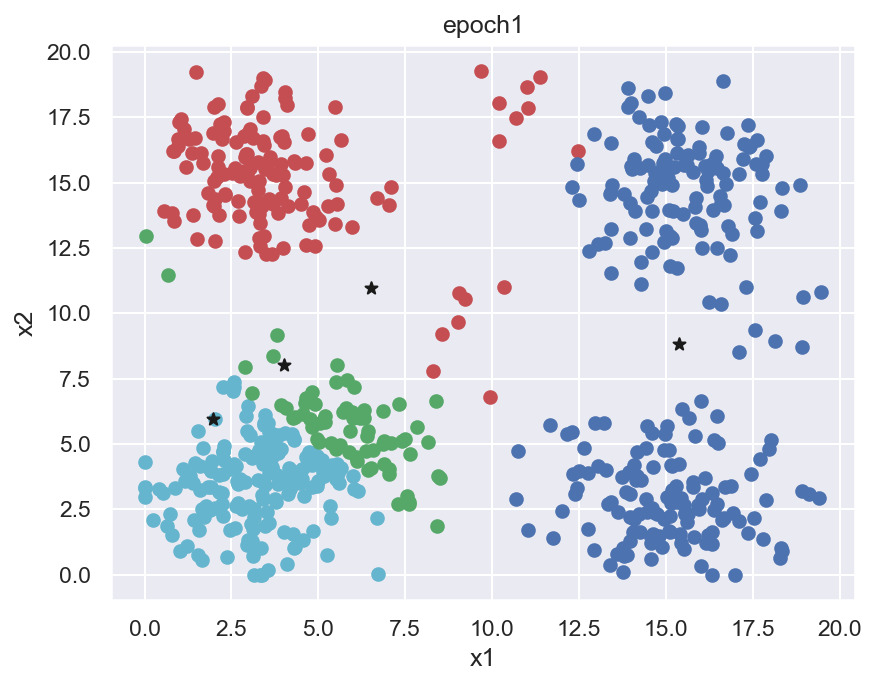

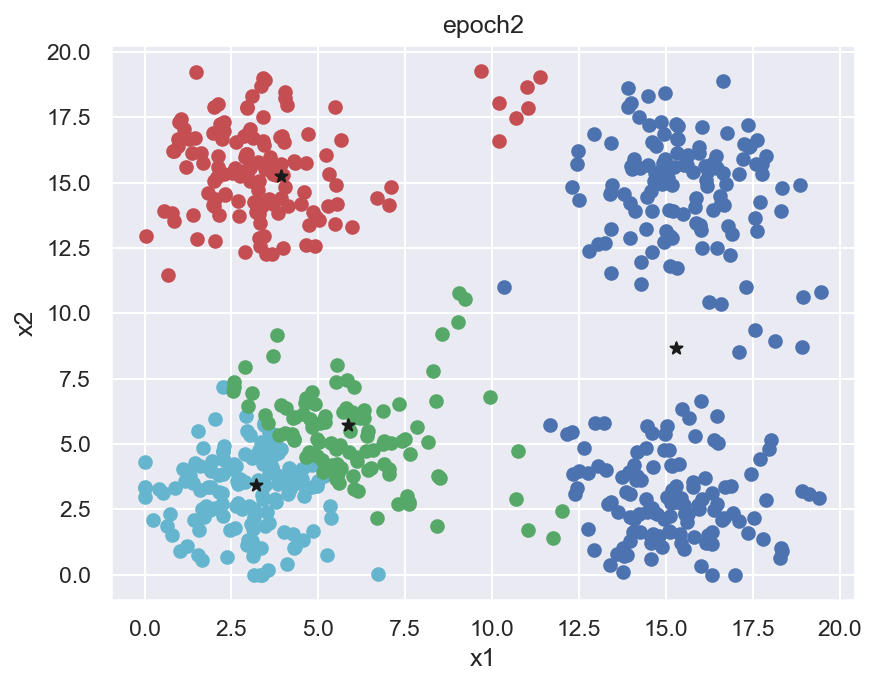

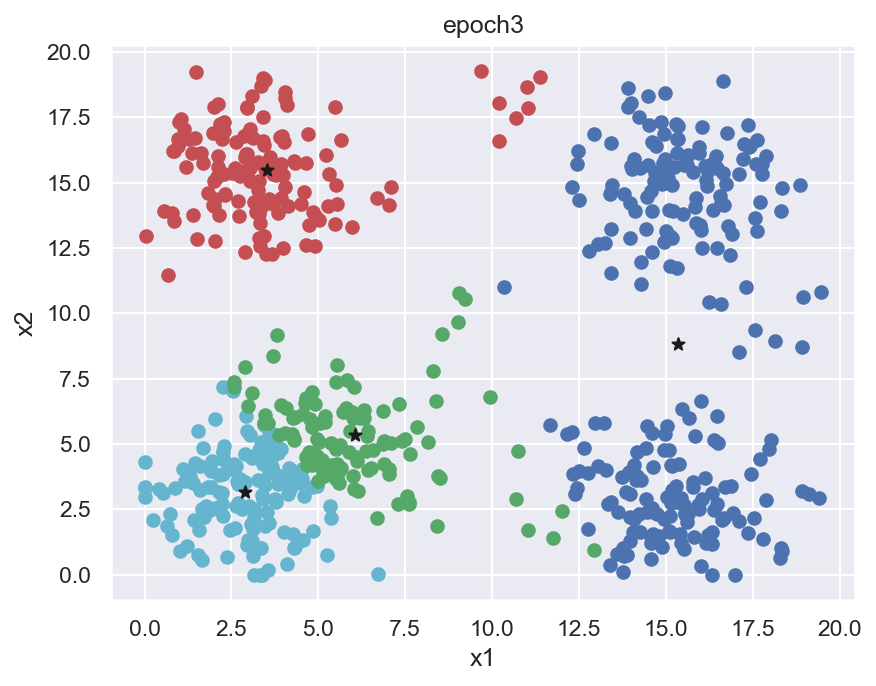

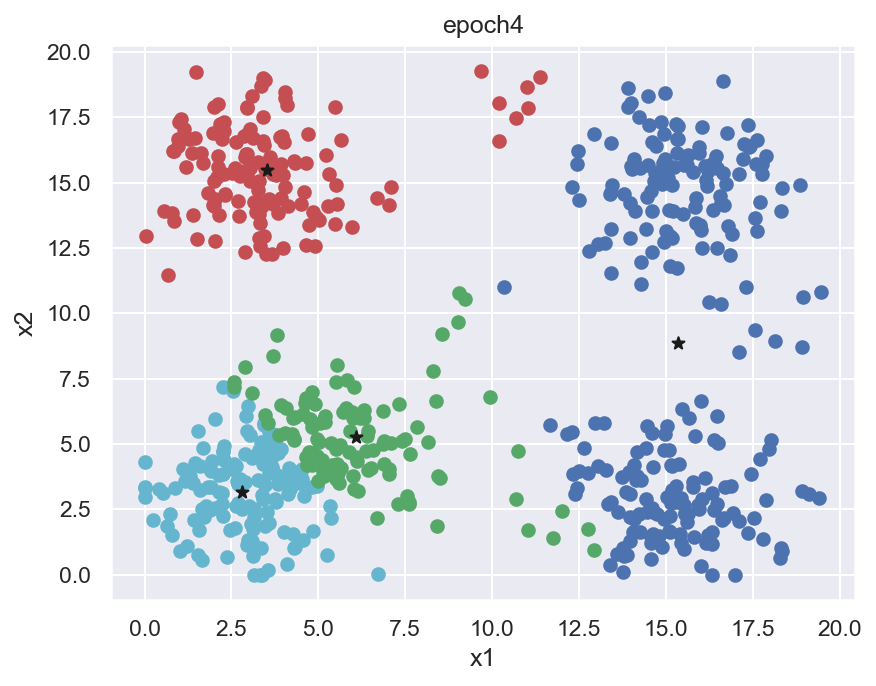

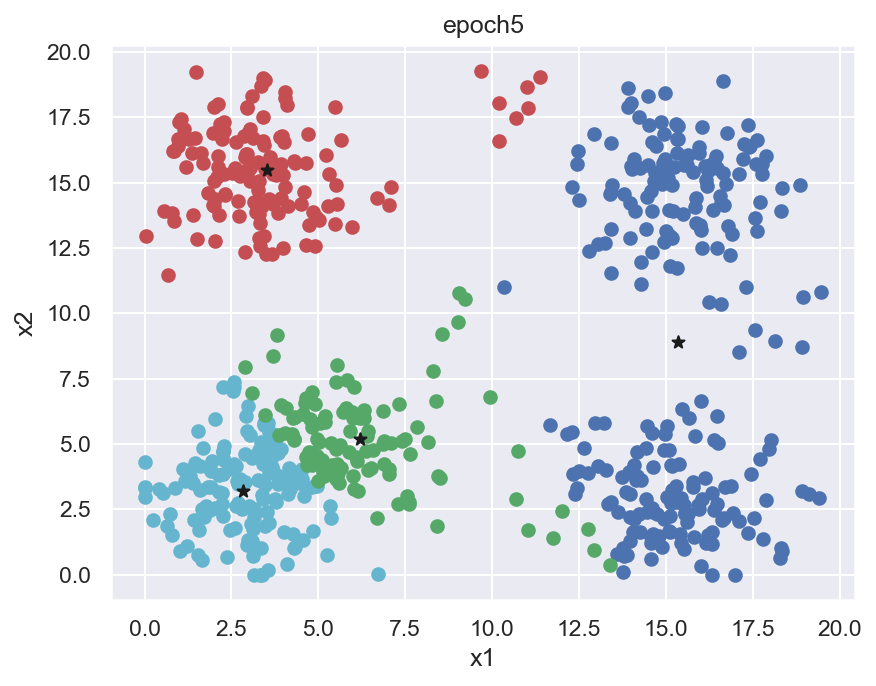

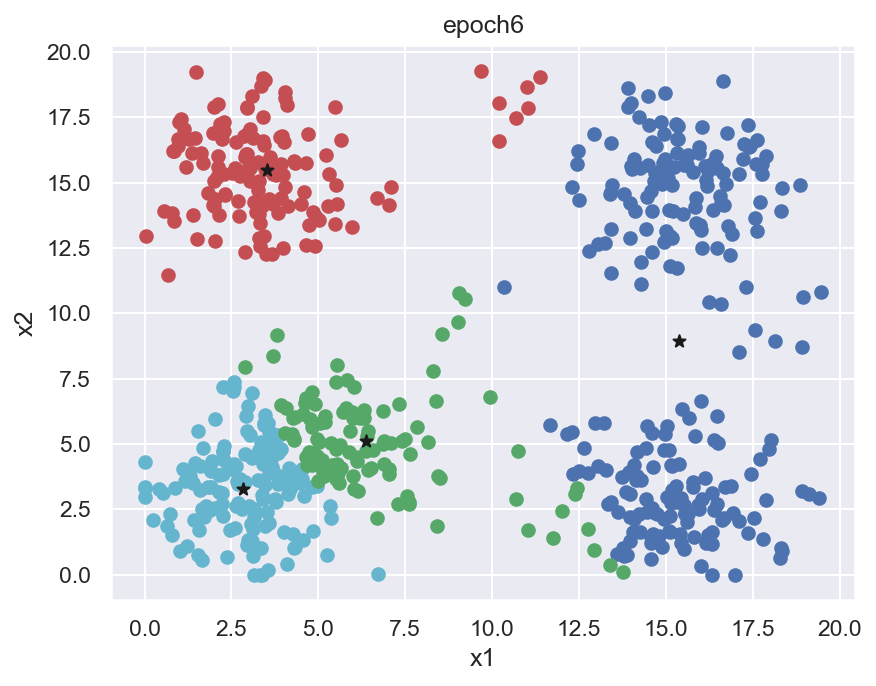

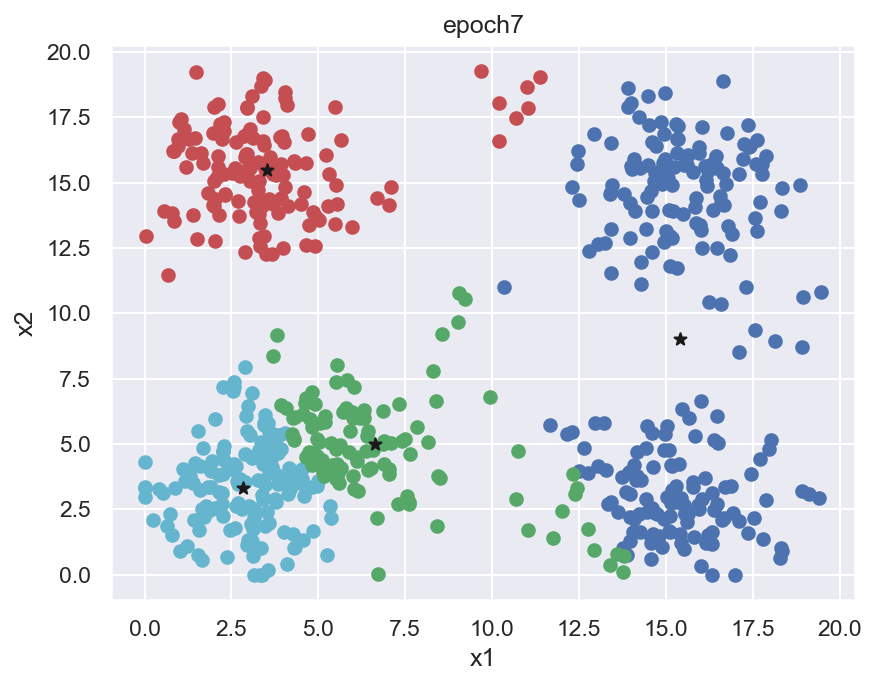

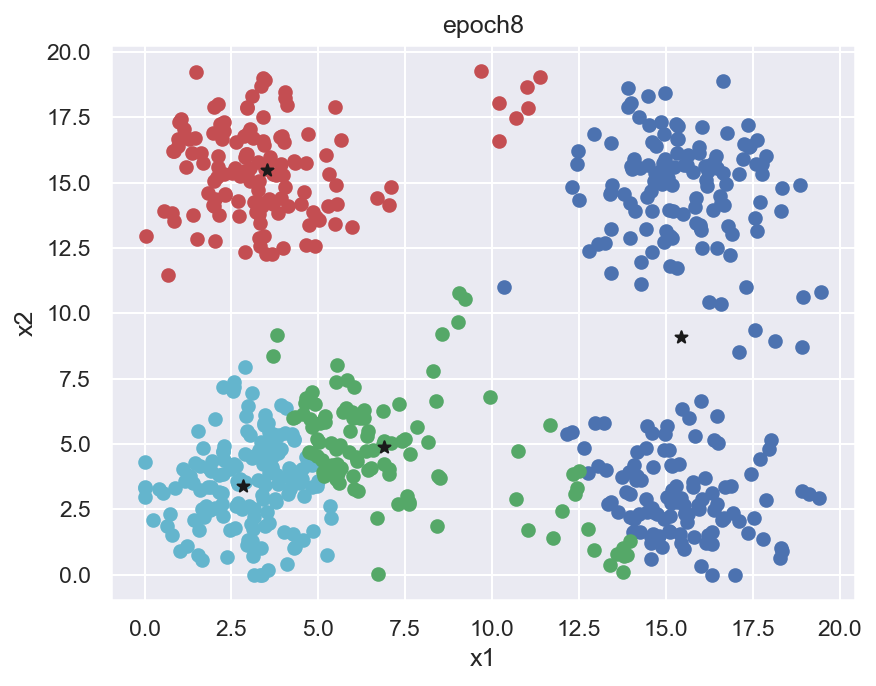

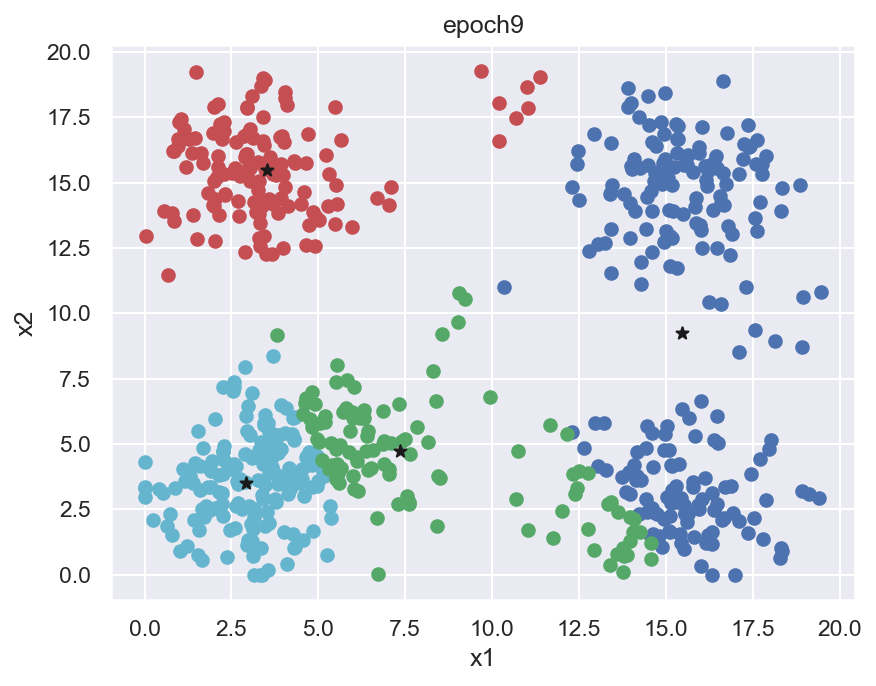

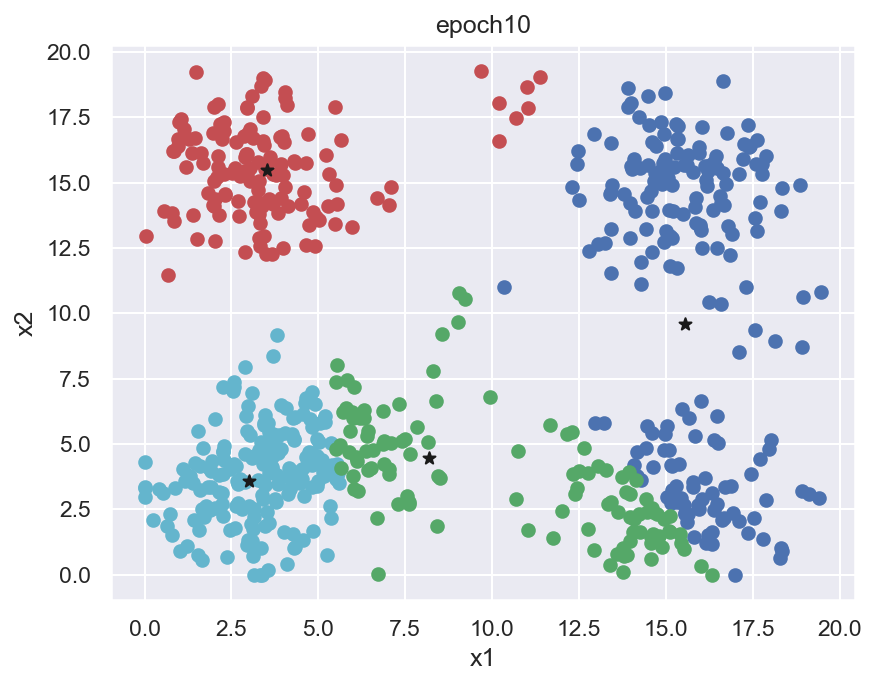

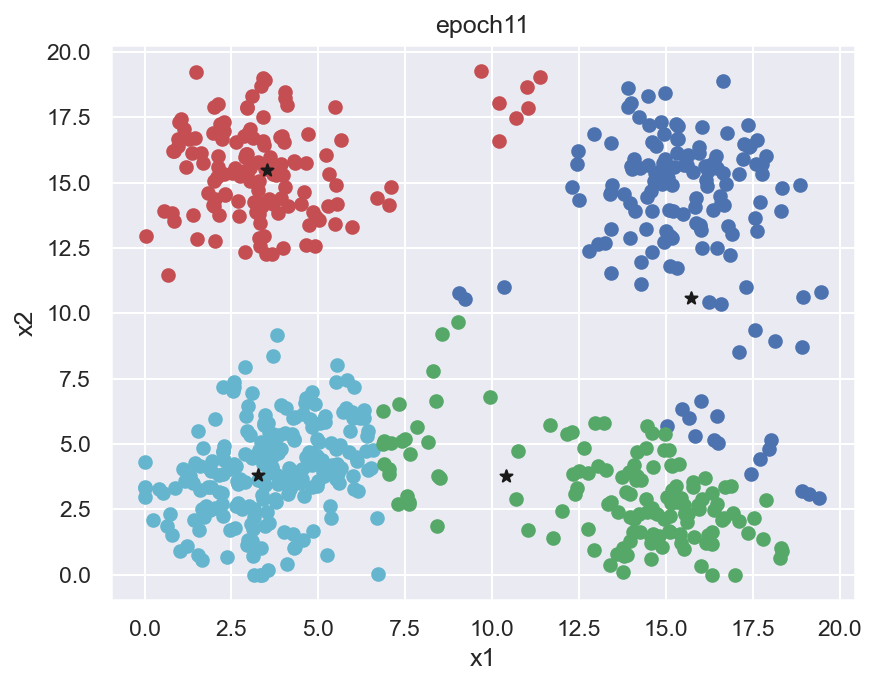

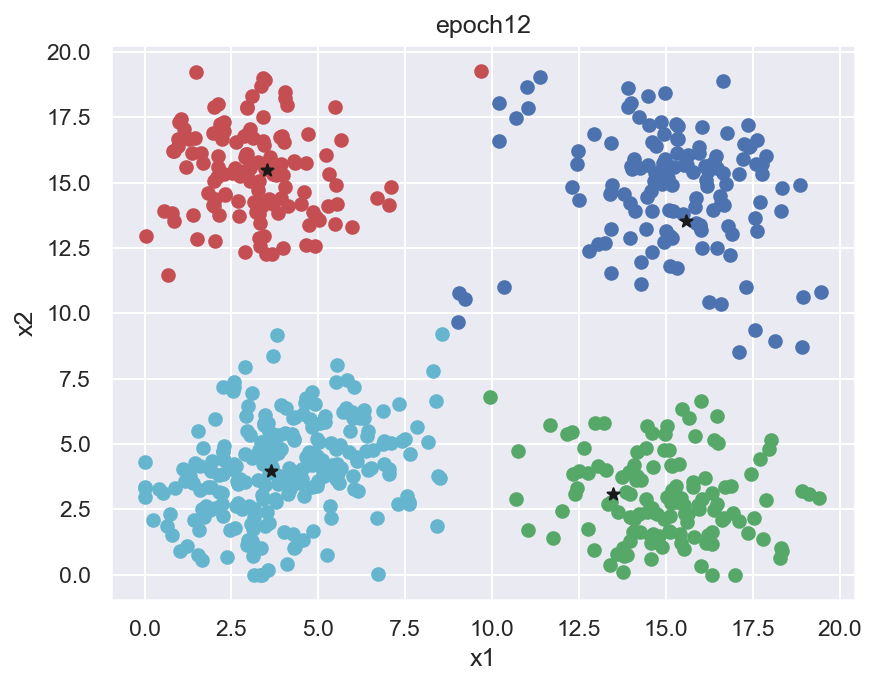

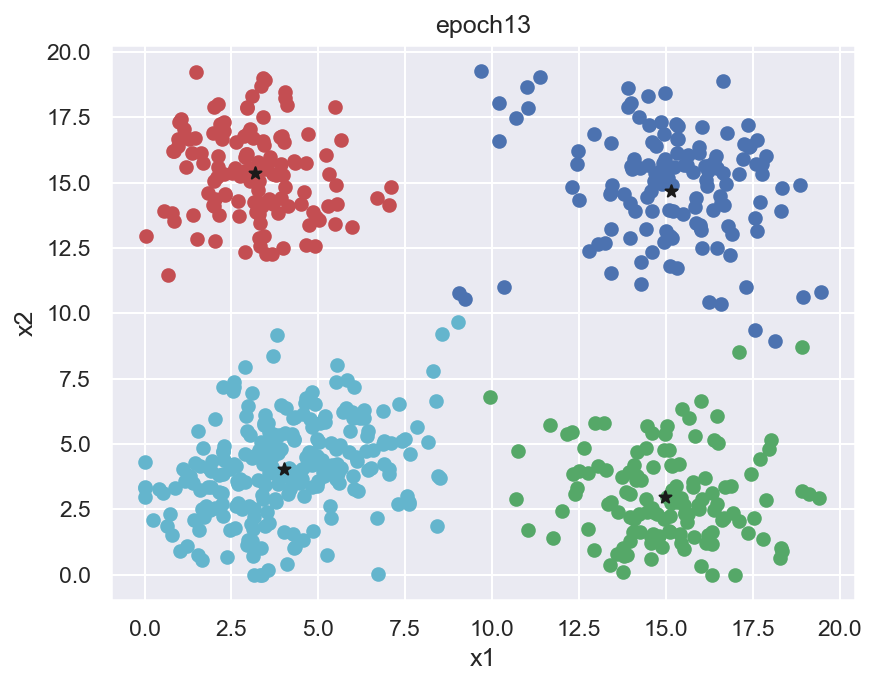

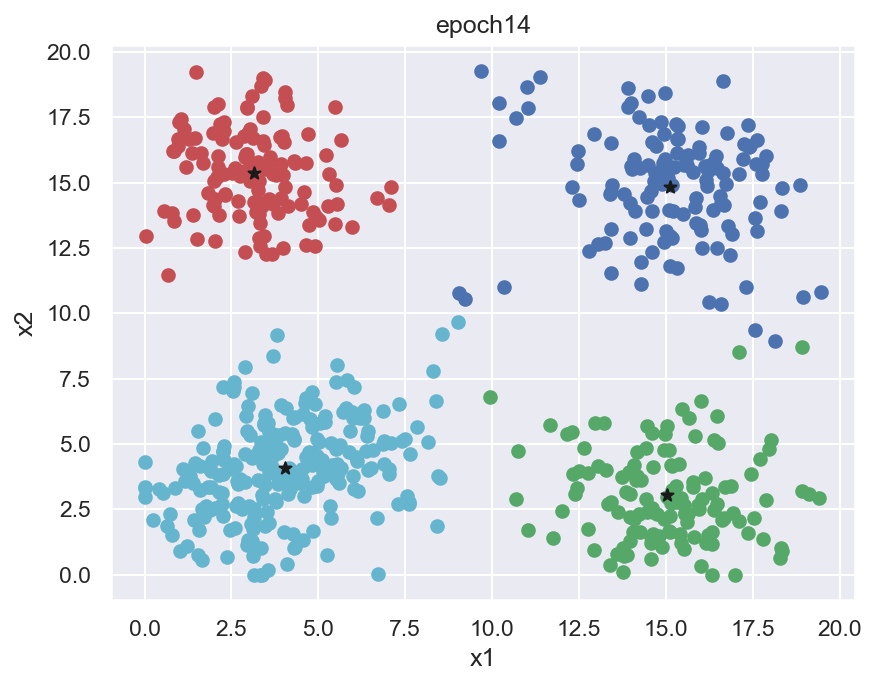

In [ ]:
assignment, _ = kmeans(X, k, max_epoch)

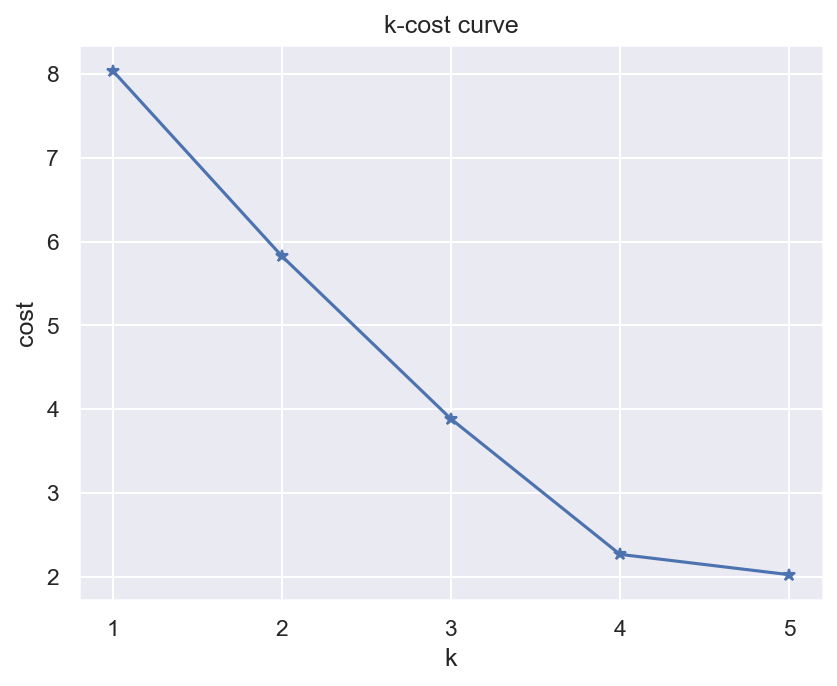

In [ ]:
#绘制簇数-代价函数曲线：根据曲线，观察最合适的簇数k的选择
plt.figure(dpi=150)
Cost = []
max_k = 6
for k in range(1, max_k):
    _, cost = kmeans(X, k, max_epoch,False)
    Cost.append(cost)

plt.plot(range(1,max_k), Cost, c='b', marker = '*')
plt.xticks(range(1,max_k))
plt.xlabel('k')
plt.ylabel('cost')
plt.title('k-cost curve')
plt.show()